In [34]:
import numpy as np
import librosa
import sys
print("Python:", sys.version)
print("NumPy:", np.__version__)
print("NumPy file:", np.__file__)
print("Librosa:", librosa.__version__)
print("Librosa file:", librosa.__file__)

Python: 3.10.13 | packaged by Anaconda, Inc. | (main, Sep 11 2023, 13:15:57) [MSC v.1916 64 bit (AMD64)]
NumPy: 1.26.4
NumPy file: C:\Users\horag\anaconda3\envs\py310_env\lib\site-packages\numpy\__init__.py
Librosa: 0.11.0
Librosa file: C:\Users\horag\anaconda3\envs\py310_env\lib\site-packages\librosa\__init__.py


In [1]:
from tensorflow.keras.models import load_model
import tensorflow as tf
from tensorflow.keras import backend as K

def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        pt = tf.where(tf.equal(y_true,1), y_pred, 1-y_pred)
        return -K.mean(alpha * K.pow(1-pt,gamma) * K.log(pt))
    return loss

model = load_model("covid_cough_model.h5", custom_objects={"loss": focal_loss()})
print("Model loaded successfully!")





Model loaded successfully!


In [1]:
import os
import librosa
import librosa.display
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from IPython.display import Audio

from gammatone.gtgram import gtgram
from skimage.transform import resize   # NEW


In [2]:
BASE = "data"

CLEAN_POS = f"{BASE}/clean_cough/Positive"
CLEAN_NEG = f"{BASE}/clean_cough/Negative"

NOISE = f"{BASE}/noise/audio"

MIXED_POS = f"{BASE}/mixed_cough/Positive"
MIXED_NEG = f"{BASE}/mixed_cough/Negative"

os.makedirs(MIXED_POS, exist_ok=True)
os.makedirs(MIXED_NEG, exist_ok=True)

In [3]:
def mix_with_noise(clean_path, noise_files, snr_db):
    clean, sr = librosa.load(clean_path, sr=16000)
    noise_file = random.choice(noise_files)
    noise, _ = librosa.load(noise_file, sr=16000)

    if len(noise) < len(clean):
        noise = np.tile(noise, int(len(clean)/len(noise)) + 1)

    noise = noise[:len(clean)]

    clean_power = np.mean(clean**2)
    noise_power = np.mean(noise**2)
    target_noise_power = clean_power / (10**(snr_db/10))
    noise = noise * np.sqrt(target_noise_power / noise_power)

    mixed = clean + noise
    return mixed, sr


In [4]:
import soundfile as sf

noise_files = [NOISE + "/" + f for f in os.listdir(NOISE) if f.endswith(".wav")]
snrs = [15, 20, 25, 30]    # ← MUCH BETTER than [0,5,10,20]

def process_folder(clean_folder, save_folder):
    for file in os.listdir(clean_folder):
        if not file.endswith(".wav"):
            continue
        clean_path = os.path.join(clean_folder, file)
        for snr in snrs:
            mixed, sr = mix_with_noise(clean_path, noise_files, snr)
            save_name = f"{file.replace('.wav','')}_snr{snr}.wav"
            sf.write(os.path.join(save_folder, save_name), mixed, sr, subtype="PCM_16")

process_folder(CLEAN_POS, MIXED_POS)
process_folder(CLEAN_NEG, MIXED_NEG)
print("High-quality mixed dataset created!")

C:\Users\horag\AppData\Local\Temp\ipykernel_14860\2667647853.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  noise = noise * np.sqrt(target_noise_power / noise_power)
C:\Users\horag\AppData\Local\Temp\ipykernel_14860\2667647853.py:14: RuntimeWarning: invalid value encountered in multiply
  noise = noise * np.sqrt(target_noise_power / noise_power)


High-quality mixed dataset created!


In [5]:
def extract_features(path, max_len=250):
    y, sr = librosa.load(path, sr=16000)
    
    # Light augmentation (same as before)
    if random.random() < 0.2:
        y = librosa.effects.pitch_shift(y=y, sr=sr, n_steps=random.choice([-1, 1]))
    if random.random() < 0.2:
        rate = random.uniform(0.97, 1.03)
        y = librosa.effects.time_stretch(y, rate=rate)

    # -------------------------
    # 1️⃣ MFCC Features (40)
    # -------------------------
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    if mfcc.shape[1] < max_len:
        mfcc = np.pad(mfcc, ((0,0),(0,max_len - mfcc.shape[1])), mode="constant")
    else:
        mfcc = mfcc[:, :max_len]

    # -------------------------
    # 2️⃣ Gammatone Features (64)
    # -------------------------
    gt = gtgram(
        y,
        fs=sr,
        window_time=0.025,
        hop_time=0.010,
        channels=64,
        f_min=50
    )  # shape → (64, T)

    # Resize to (64, max_len)
    gt = resize(gt, (64, max_len), mode="constant")

    # -------------------------
    # 3️⃣ Combine MFCC + Gammatone
    # -------------------------
    combined = np.vstack([mfcc, gt])  # shape → (104, max_len)

    return np.expand_dims(combined, axis=-1)  # final shape → (104, 250, 1)

In [6]:
X, Y = [], []

def load_data(folder, label):
    for f in os.listdir(folder):
        if f.endswith(".wav"):
            feat = extract_features(folder + "/" + f)
            X.append(feat)
            Y.append(label)

load_data(MIXED_POS, 1)   # Positive
load_data(MIXED_NEG, 0)   # Negative

X = np.array(X)
Y = to_categorical(np.array(Y))

print(X.shape, Y.shape)

(26299, 104, 250, 1) (26299, 2)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)
print("Training samples:", len(X_train))


Training samples: 21039


In [8]:
input_shape = (104, 250, 1)   # UPDATED

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding="same", input_shape=input_shape),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu', padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu', padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    layers.Reshape((-1, 128)),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dropout(0.4),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(2, activation='softmax')
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()





Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 104, 250, 32)      320       
                                                                 
 batch_normalization (Batch  (None, 104, 250, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 52, 125, 32)       0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 52, 125, 32)       0         
                                                                 
 conv2d_1 (Conv2D)           (None, 52, 125, 64)       18496     
                                                                 
 batch_normalization_1 (Bat  (None, 52, 125, 64)     

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

es = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1)

callbacks = [es, reduce_lr]

In [10]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=120,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/120


1315/1315 [==============================] - 327s 239ms/step - loss: 0.6489 - accuracy: 0.6367 - val_loss: 0.6221 - val_accuracy: 0.6464 - lr: 0.0010
Epoch 2/120
1315/1315 [==============================] - 304s 231ms/step - loss: 0.6059 - accuracy: 0.6811 - val_loss: 0.6008 - val_accuracy: 0.6781 - lr: 0.0010
Epoch 3/120
1315/1315 [==============================] - 306s 233ms/step - loss: 0.5701 - accuracy: 0.7176 - val_loss: 0.5463 - val_accuracy: 0.7361 - lr: 0.0010
Epoch 4/120
1315/1315 [==============================] - 305s 232ms/step - loss: 0.5350 - accuracy: 0.7384 - val_loss: 0.5104 - val_accuracy: 0.7409 - lr: 0.0010
Epoch 5/120
1315/1315 [==============================] - 305s 232ms/step - loss: 0.5073 - accuracy: 0.7563 - val_loss: 0.4502 - val_accuracy: 0.7933 - lr: 0.0010
Epoch 6/120
1315/1315 [==============================] - 304s 231ms/step - loss: 0.4652 - accuracy: 0.7863 - val_loss: 0.4228 - val_accuracy: 0.8148 - lr: 0.0010
Epoch 7/120
1315/1315 [===

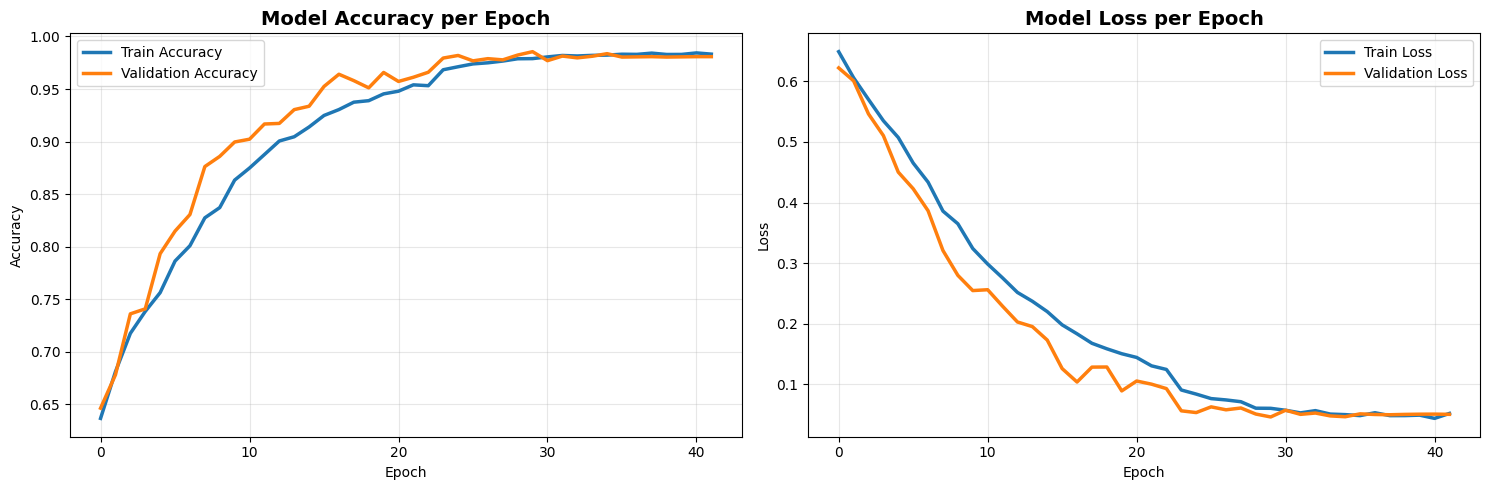

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2.5)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2.5)
plt.title('Model Accuracy per Epoch', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2.5)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2.5)
plt.title('Model Loss per Epoch', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
model.save("covid_cough_model.h5")
print("Model saved!")


Model saved!


C:\Users\horag\anaconda3\envs\py310_env\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [15]:
pip install sounddevice scipy


Note: you may need to restart the kernel to use updated packages.


In [13]:
import sounddevice as sd
from scipy.io.wavfile import write


def record_cough(sec=3):
    print("Recording...")
    fs = 16000
    data = sd.rec(int(sec * fs), samplerate=fs, channels=1)
    sd.wait()
    write("live.wav", fs, data)
    print("Saved live.wav")

record_cough()

feat = extract_features("live.wav")
feat = np.expand_dims(feat, axis=0)

pred = model.predict(feat)
print("COVID Positive" if np.argmax(pred)==1 else "COVID Negative")


Recording...
Saved live.wav
1/1 [==============================] - 1s 515ms/step
COVID Negative
